<a href="https://colab.research.google.com/github/Aswinpt2004/Deep-Learning/blob/main/Dl_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [ ]:
df = pd.read_csv('AirPassengers.csv')

# Convert 'Month' column to datetime and set it as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print(df.head())


            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


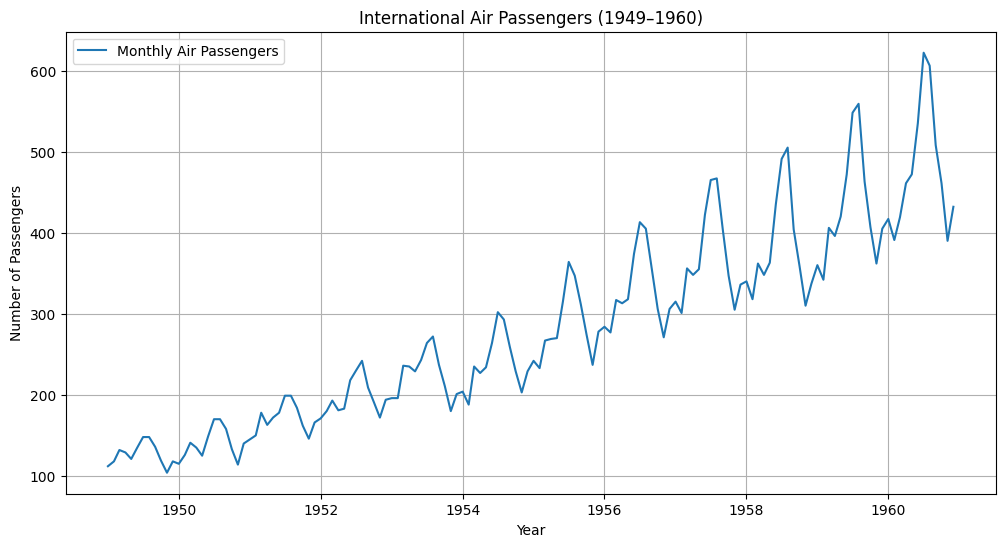

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df, label='Monthly Air Passengers')
plt.title('International Air Passengers (1949–1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.legend()
plt.show()


LSTMs perform better with scaled data. We use MinMaxScaler to scale data between 0 and 1


In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values.astype('float32'))

# View the first few scaled values
print(scaled_data[:5])


[[0.01544401]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]]


Create Input Sequences for LSTM


In [ ]:
# Function to generate sequences: past `window_size` values → predict next value

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

# Set window size (number of time steps for prediction)
window_size = 12  # using last 12 months to predict the next

# Create sequences
X, y = create_sequences(scaled_data, window_size)

# Reshape X to match LSTM input format: (samples, time steps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print("Input shape for LSTM:", X.shape)


Input shape for LSTM: (132, 12, 1)


 Build the LSTM Model

In [ ]:
# A simple LSTM model: 1 LSTM layer and 1 Dense output layer

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(window_size, 1)))
model.add(Dense(1))  # One output value (next month)

# Compile the model with mean squared error loss and Adam optimizer
model.compile(optimizer='adam', loss='mse')


In [ ]:
# Train the model with the training data
history = model.fit(X, y, epochs=200, verbose=0)  # You can set verbose=1 to see progress


 Make Predictions and Inverse Scale

In [ ]:
# Predict using the trained model
y_pred = model.predict(X)

y_pred_inv = scaler.inverse_transform(y_pred)
y_true_inv = scaler.inverse_transform(y)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


Compare predicted and actual values visually


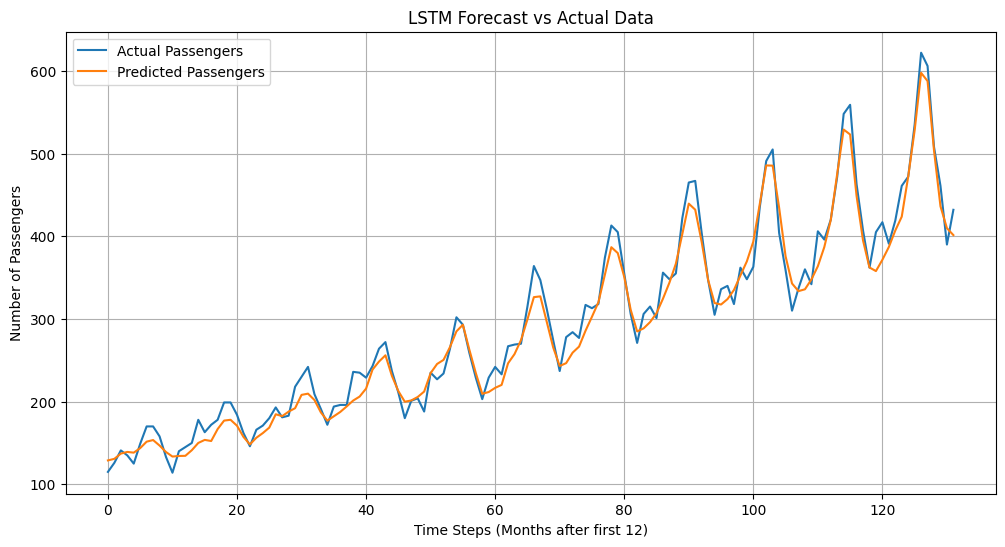

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_true_inv, label='Actual Passengers')
plt.plot(y_pred_inv, label='Predicted Passengers')
plt.title('LSTM Forecast vs Actual Data')
plt.xlabel('Time Steps (Months after first 12)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()
